# Go Scheduler Deep Dive

1. How the Go Scheduler Works (GMP Model)
2. How a Goroutine Blocks
3. When a Goroutine Block Causes the Underlying Thread to Block
4. How Messages Are Delivered to a Goroutine Blocked on a Channel
5. How a Sender Blocks When a Channel Is Full
6. How a Goroutine Resumes
7. How `select` Works
8. How a Goroutine Blocked on a Channel Resumes

In [ ]:
from IPython.display import Image, display
import base64, requests

def mermaid(diagram: str):
    """Render a Mermaid diagram as a PNG image via mermaid.ink."""
    encoded = base64.urlsafe_b64encode(diagram.encode()).decode()
    resp = requests.get(f"https://mermaid.ink/img/{encoded}")
    resp.raise_for_status()
    display(Image(data=resp.content))

---
## 1. How the Go Scheduler Works (GMP Model)

Go uses a **cooperative, work-stealing, M:N scheduler** that multiplexes **G**oroutines onto **M** OS threads using **P** processors.

### The Three Core Entities

| Entity | What It Is | Quantity |
|--------|-----------|----------|
| **G** (Goroutine) | A lightweight user-space thread (~2-8 KB stack) | Millions possible |
| **M** (Machine) | An OS thread managed by the runtime | Typically ≤ 10,000 |
| **P** (Processor) | A logical processor / scheduling context | `GOMAXPROCS` (default = num CPU cores) |

### Key Rule: A goroutine runs only when a **G** is bound to an **M** through a **P**.

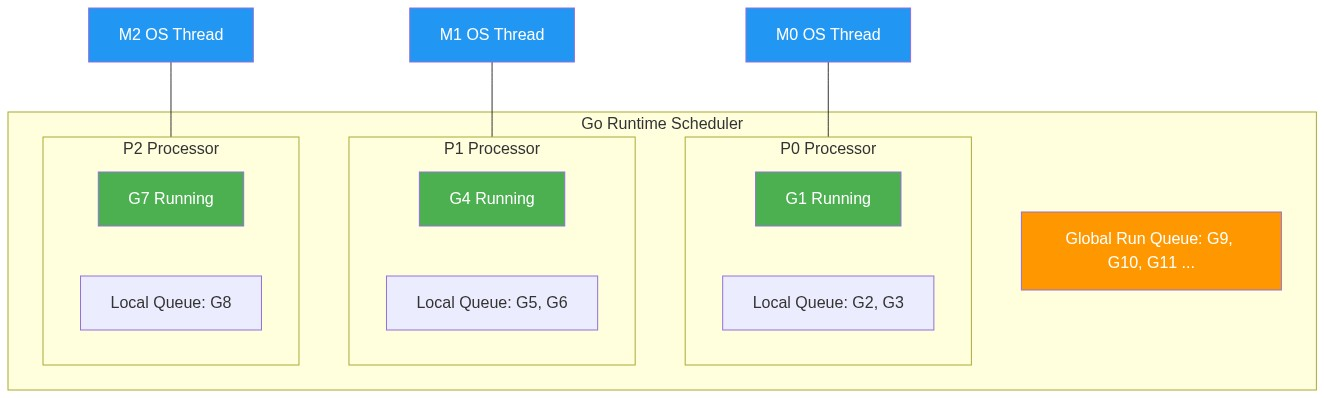

In [ ]:
mermaid("""graph TB
    subgraph Scheduler["Go Runtime Scheduler"]
        subgraph P0["P0 Processor"]
            G1["G1 Running"]
            LQ0["Local Queue: G2, G3"]
        end
        subgraph P1["P1 Processor"]
            G4["G4 Running"]
            LQ1["Local Queue: G5, G6"]
        end
        subgraph P2["P2 Processor"]
            G7["G7 Running"]
            LQ2["Local Queue: G8"]
        end
        GRQ["Global Run Queue: G9, G10, G11 ..."]
    end

    M0["M0 OS Thread"] --- P0
    M1["M1 OS Thread"] --- P1
    M2["M2 OS Thread"] --- P2

    style G1 fill:#4CAF50,color:#fff
    style G4 fill:#4CAF50,color:#fff
    style G7 fill:#4CAF50,color:#fff
    style GRQ fill:#FF9800,color:#fff
    style M0 fill:#2196F3,color:#fff
    style M1 fill:#2196F3,color:#fff
    style M2 fill:#2196F3,color:#fff""")


### Scheduling Lifecycle

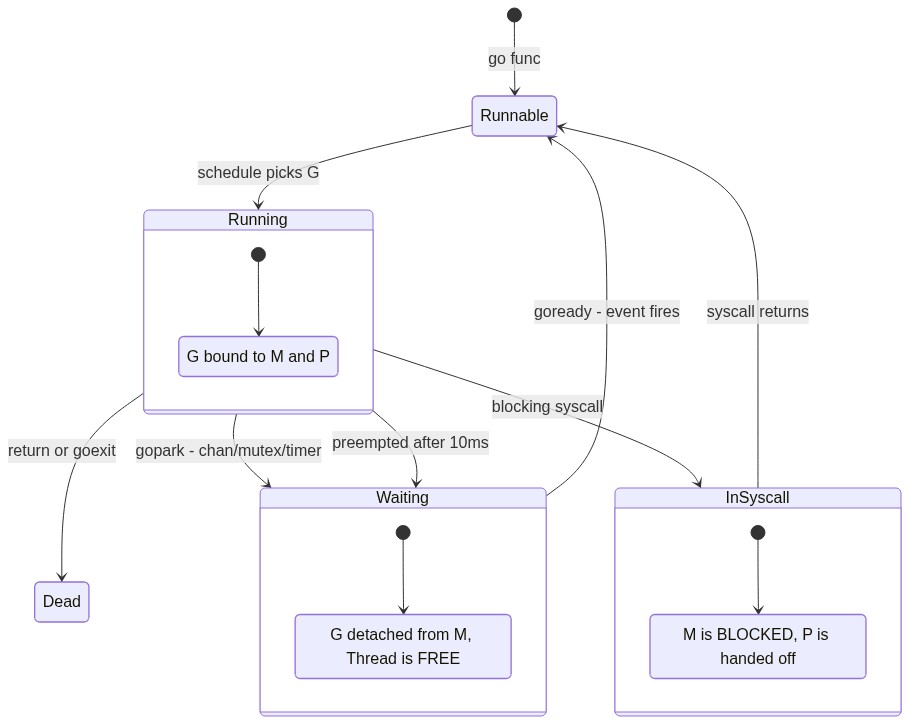

In [ ]:
mermaid("""stateDiagram-v2
    [*] --> Runnable : go func
    Runnable --> Running : schedule picks G
    Running --> Dead : return or goexit
    Running --> Waiting : gopark - chan/mutex/timer
    Running --> Waiting : preempted after 10ms
    Running --> InSyscall : blocking syscall
    Waiting --> Runnable : goready - event fires
    InSyscall --> Runnable : syscall returns

    state Running {
        [*] --> executing
        executing : G bound to M and P
    }
    state Waiting {
        [*] --> parked
        parked : G detached from M, Thread is FREE
    }
    state InSyscall {
        [*] --> in_kernel
        in_kernel : M is BLOCKED, P is handed off
    }""")


### How Work Stealing Keeps Things Busy

When a **P** runs out of goroutines in its local queue:

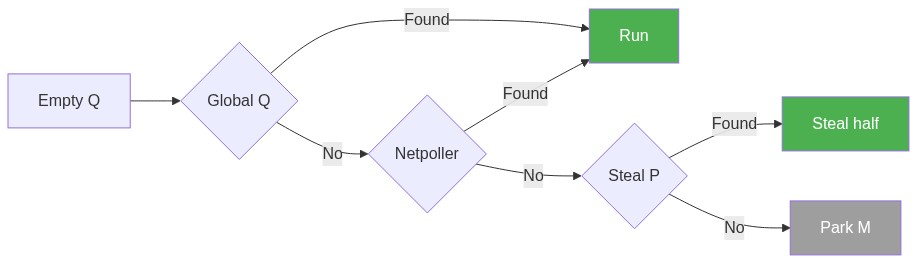

In [ ]:
mermaid("""flowchart LR
    A["Empty Q"] --> B{"Global Q"}
    B -->|Found| R["Run"]
    B -->|No| C{"Netpoller"}
    C -->|Found| R
    C -->|No| D{"Steal P"}
    D -->|Found| S["Steal half"]
    D -->|No| E["Park M"]

    style R fill:#4CAF50,color:#fff
    style S fill:#4CAF50,color:#fff
    style E fill:#9E9E9E,color:#fff""")


### Cooperative Preemption Points

Goroutines yield at:
- **Function call prologues** (stack-growth check)
- **Channel operations** (send/receive)
- **System calls** (file I/O, network I/O)
- **`runtime.Gosched()`** explicit yield
- **Async preemption signals** (Go 1.14+): runtime sends `SIGURG` to preempt long-running goroutines without function calls (e.g., tight `for {}` loops)

---
## 2. How a Goroutine Blocks

A goroutine **blocks** when it needs to wait for an event before it can continue. The scheduler **detaches** the goroutine from the P so other goroutines can use the CPU.

### Types of Blocking Operations

| Category | Operations | Blocks OS Thread? |
|----------|-----------|-------------------|
| **Channel** | `ch <- val` (full/unbuffered), `<-ch` (empty) | No |
| **Synchronization** | `sync.Mutex.Lock()`, `WaitGroup.Wait()`, `Cond.Wait()` | No |
| **Network I/O** | `net.Conn.Read/Write`, `time.Sleep` | No (netpoller) |
| **Disk I/O** | `os.Open`, `os.Read`, `os.Write` | **Yes** |
| **CGO** | `C.somefunc()` | **Yes** |
| **Syscall** | `syscall.Read` etc. | **Yes** |
| **Select** | `select { ... }` with no ready case | No |
| **GC** | Stop-The-World phases | No |

### What Happens Internally When a Goroutine Blocks (Channel Receive)

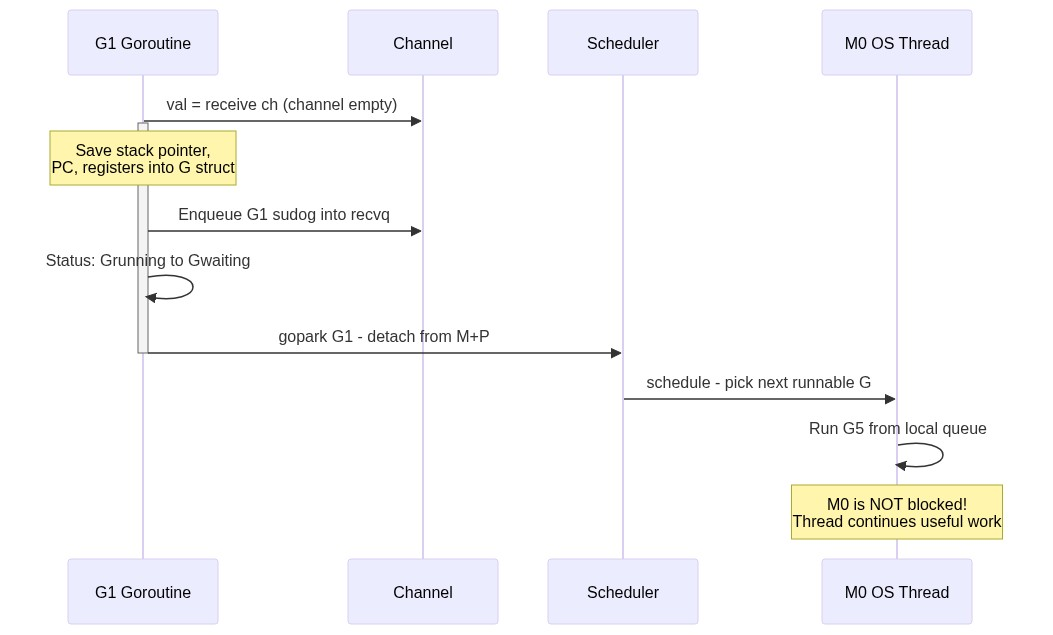

In [ ]:
mermaid("""sequenceDiagram
    participant G1 as G1 Goroutine
    participant CH as Channel
    participant SCHED as Scheduler
    participant M as M0 OS Thread

    G1->>CH: val = receive ch (channel empty)
    activate G1
    Note over G1: Save stack pointer,<br/>PC, registers into G struct
    G1->>CH: Enqueue G1 sudog into recvq
    G1->>G1: Status: Grunning to Gwaiting
    G1->>SCHED: gopark G1 - detach from M+P
    deactivate G1
    SCHED->>M: schedule - pick next runnable G
    M->>M: Run G5 from local queue
    Note over M: M0 is NOT blocked!<br/>Thread continues useful work""")


> **Key insight**: When a goroutine blocks on a channel/mutex/timer, it does **NOT** block the OS thread. The goroutine is simply **parked** and the thread runs another goroutine.

---
## 3. When a Goroutine Block Causes the Underlying Thread to Block

Most goroutine blocks are **user-space parks** — the OS thread stays free. But some operations **truly block the OS thread**.

### The Handoff Mechanism

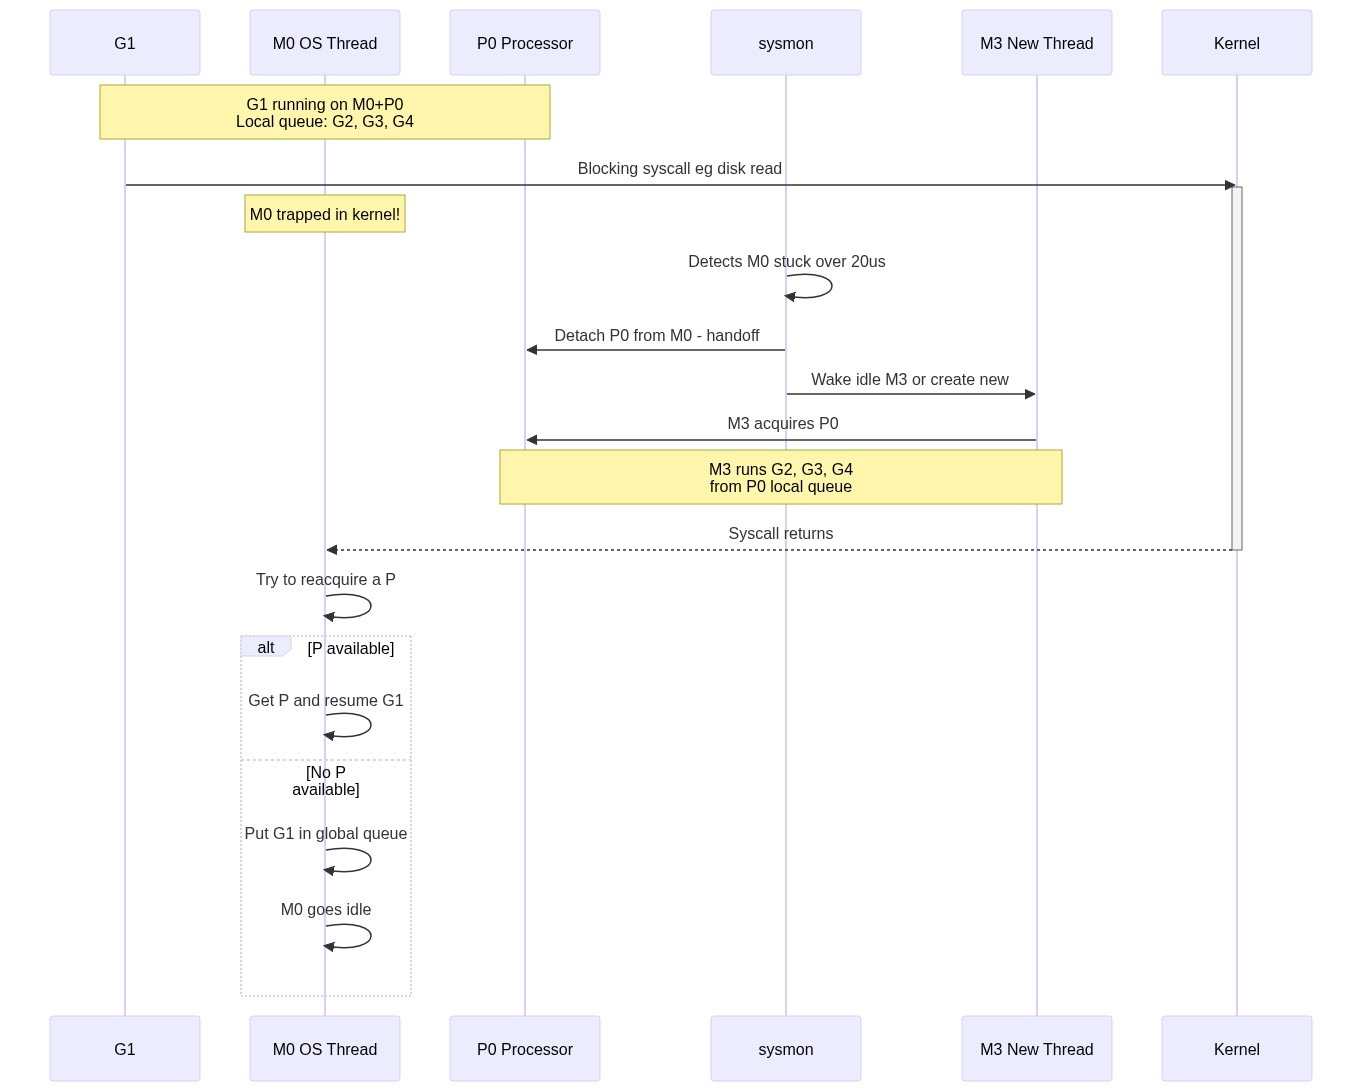

In [ ]:
mermaid("""sequenceDiagram
    participant G1 as G1
    participant M0 as M0 OS Thread
    participant P0 as P0 Processor
    participant SM as sysmon
    participant M3 as M3 New Thread
    participant K as Kernel

    Note over G1,P0: G1 running on M0+P0<br/>Local queue: G2, G3, G4

    G1->>K: Blocking syscall eg disk read
    activate K
    Note over M0: M0 trapped in kernel!

    SM->>SM: Detects M0 stuck over 20us
    SM->>P0: Detach P0 from M0 - handoff
    SM->>M3: Wake idle M3 or create new
    M3->>P0: M3 acquires P0
    Note over M3,P0: M3 runs G2, G3, G4<br/>from P0 local queue

    K-->>M0: Syscall returns
    deactivate K
    M0->>M0: Try to reacquire a P
    alt P available
        M0->>M0: Get P and resume G1
    else No P available
        M0->>M0: Put G1 in global queue
        M0->>M0: M0 goes idle
    end""")


### Operations That Block the OS Thread

| Operation | Why It Blocks the Thread | Mitigation |
|-----------|-------------------------|------------|
| **Disk I/O** (`os.Open`, `os.Read`) | Kernel doesn't provide async disk I/O on all platforms | Thread handoff; P reassigned to new M |
| **CGO calls** (`C.somefunc()`) | Go runtime can't control C code execution | Thread handoff; may spawn new M |
| **Blocking syscalls** (`syscall.Read`) | Thread trapped in kernel | `sysmon` detects after 20us, triggers handoff |
| **`runtime.LockOSThread()`** | Explicit request (e.g., OpenGL, thread-local storage) | P stays with M; other Gs in queue wait or are stolen |
| **DNS resolution** (on some OS) | Uses C library (`cgo`) which blocks | Pure-Go resolver avoids this |

### The `sysmon` Thread

The runtime runs a special background thread called **sysmon** (system monitor):

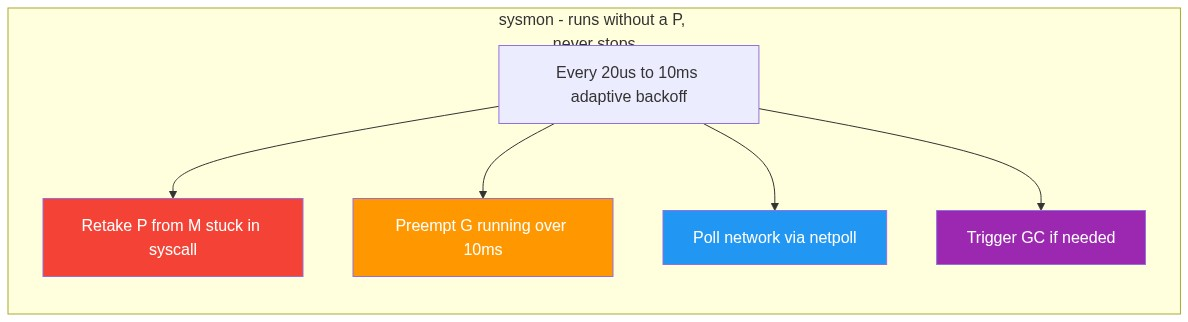

In [ ]:
mermaid("""flowchart LR
    subgraph SYSMON["sysmon - runs without a P, never stops"]
        direction TB
        A["Every 20us to 10ms adaptive backoff"]
        A --> B["Retake P from M stuck in syscall"]
        A --> C["Preempt G running over 10ms"]
        A --> D["Poll network via netpoll"]
        A --> E["Trigger GC if needed"]
    end

    style B fill:#f44336,color:#fff
    style C fill:#FF9800,color:#fff
    style D fill:#2196F3,color:#fff
    style E fill:#9C27B0,color:#fff""")


### Network I/O: The Smart Exception

Network I/O **does NOT block the OS thread** because Go uses the **netpoller** (built on `epoll`/`kqueue`/`IOCP`):

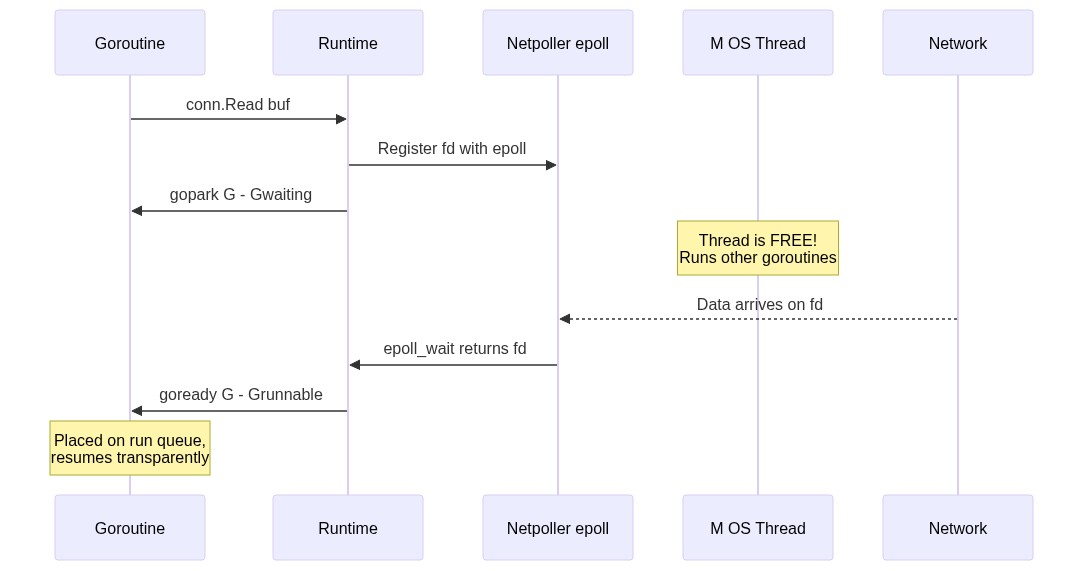

In [ ]:
mermaid("""sequenceDiagram
    participant G as Goroutine
    participant RT as Runtime
    participant EP as Netpoller epoll
    participant M as M OS Thread
    participant NW as Network

    G->>RT: conn.Read buf
    RT->>EP: Register fd with epoll
    RT->>G: gopark G - Gwaiting
    Note over M: Thread is FREE!<br/>Runs other goroutines

    NW-->>EP: Data arrives on fd
    EP->>RT: epoll_wait returns fd
    RT->>G: goready G - Grunnable
    Note over G: Placed on run queue,<br/>resumes transparently""")


> Thread is **NEVER** blocked! This is why Go handles 10K+ concurrent network connections efficiently.

---
## 4. How Messages Are Delivered to a Goroutine Blocked on a Channel

Channels are the primary communication mechanism. Let's look at the internal structure first.

### Channel Internal Structure (runtime.hchan)

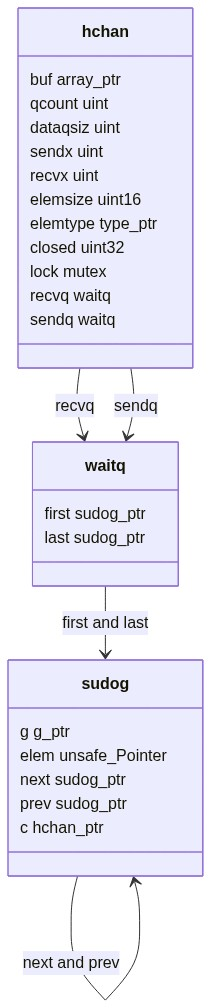

In [ ]:
mermaid("""classDiagram
    class hchan {
        buf array_ptr
        qcount uint
        dataqsiz uint
        sendx uint
        recvx uint
        elemsize uint16
        elemtype type_ptr
        closed uint32
        lock mutex
        recvq waitq
        sendq waitq
    }
    class waitq {
        first sudog_ptr
        last sudog_ptr
    }
    class sudog {
        g g_ptr
        elem unsafe_Pointer
        next sudog_ptr
        prev sudog_ptr
        c hchan_ptr
    }
    hchan --> waitq : recvq
    hchan --> waitq : sendq
    waitq --> sudog : first and last
    sudog --> sudog : next and prev""")


- **buf**: Ring buffer for buffered channels (nil for unbuffered)
- **recvq**: Linked list of goroutines blocked on `<-ch`
- **sendq**: Linked list of goroutines blocked on `ch <-`
- **sudog**: Represents a waiting goroutine + pointer to where the value should go

### Do Channel Operations Use System Calls?

Channel sends/receives are **almost entirely user-space**. But the kernel can be involved on slow paths.

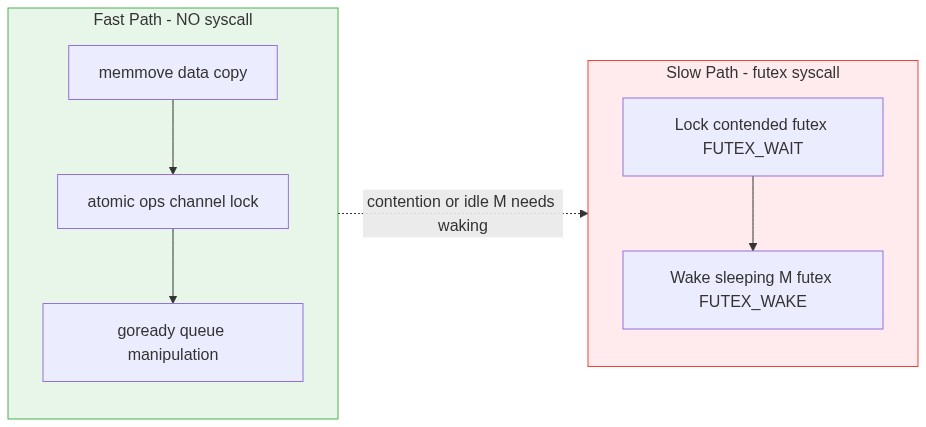

In [ ]:
mermaid("""flowchart LR
    subgraph FAST["Fast Path - NO syscall"]
        direction TB
        A["memmove data copy"] --> B["atomic ops channel lock"]
        B --> C["goready queue manipulation"]
    end
    subgraph SLOW["Slow Path - futex syscall"]
        direction TB
        D["Lock contended futex FUTEX_WAIT"] --> E["Wake sleeping M futex FUTEX_WAKE"]
    end

    FAST -.->|"contention or idle M needs waking"| SLOW

    style FAST fill:#E8F5E9,stroke:#4CAF50
    style SLOW fill:#FFEBEE,stroke:#f44336""")


| Operation | Syscall? | Details |
|-----------|----------|--------|
| `memmove` (copy value) | **No** | Pure user-space memory copy |
| `lock(&c.lock)` — uncontended | **No** | Single atomic CAS |
| `lock(&c.lock)` — contended | **Yes**: `futex(FUTEX_WAIT)` | Thread sleeps in kernel waiting for lock |
| `goready(G)` — put G in run queue | **No** | Queue insert + atomic |
| `goready(G)` — wake a parked M | **Yes**: `futex(FUTEX_WAKE)` | Kernel wakes a sleeping OS thread to run G |
| `gopark(G)` — park goroutine | **No** | User-space status change + `schedule()` |

> **In practice**: The fast path (no syscall) is the common case. The `futex` slow path only fires when there's lock contention on the channel *or* when a parked OS thread must be woken because an idle P exists.

### Case: Unbuffered Channel — Receiver Is Waiting, Sender Arrives

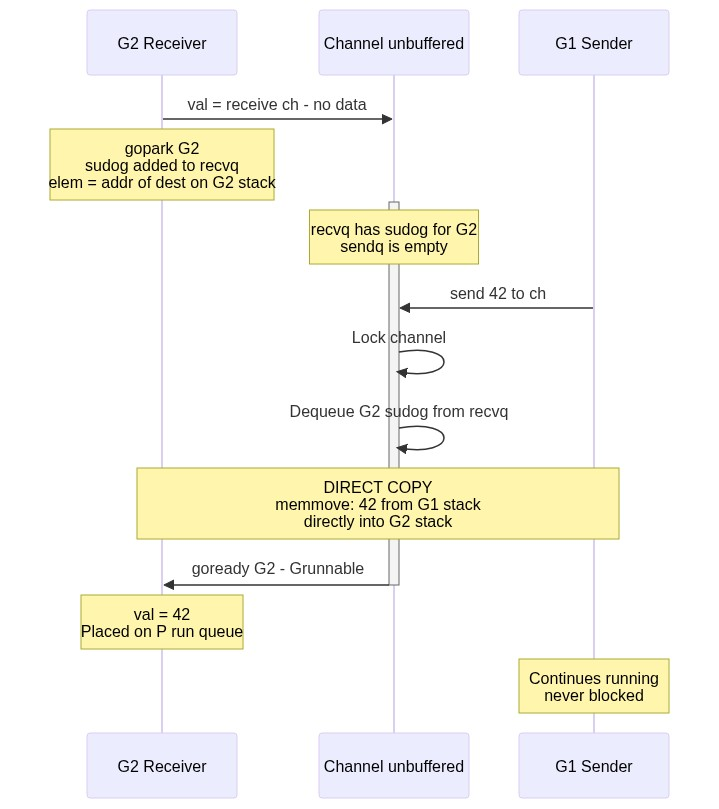

In [ ]:
mermaid("""sequenceDiagram
    participant G2 as G2 Receiver
    participant CH as Channel unbuffered
    participant G1 as G1 Sender

    G2->>CH: val = receive ch - no data
    Note over G2: gopark G2<br/>sudog added to recvq<br/>elem = addr of dest on G2 stack
    activate CH
    Note over CH: recvq has sudog for G2<br/>sendq is empty

    G1->>CH: send 42 to ch
    CH->>CH: Lock channel
    CH->>CH: Dequeue G2 sudog from recvq
    Note over G1,G2: DIRECT COPY<br/>memmove: 42 from G1 stack<br/>directly into G2 stack
    CH->>G2: goready G2 - Grunnable
    deactivate CH
    Note over G2: val = 42<br/>Placed on P run queue
    Note over G1: Continues running<br/>never blocked""")


> **Key optimization**: The sender copies the value **directly into the receiver's stack**, avoiding an extra copy through the buffer. This is called a **direct send**.

### Case: Buffered Channel — Sender Blocked (Full), Receiver Arrives

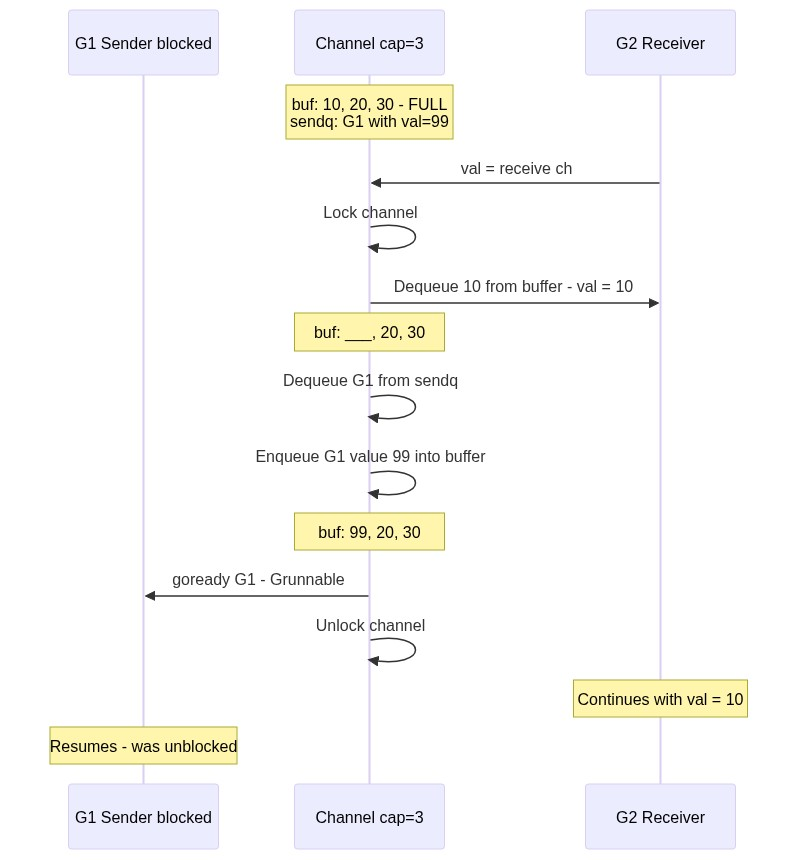

In [ ]:
mermaid("""sequenceDiagram
    participant G1 as G1 Sender blocked
    participant CH as Channel cap=3
    participant G2 as G2 Receiver

    Note over CH: buf: 10, 20, 30 - FULL<br/>sendq: G1 with val=99

    G2->>CH: val = receive ch
    CH->>CH: Lock channel
    CH->>G2: Dequeue 10 from buffer - val = 10
    Note over CH: buf: ___, 20, 30
    CH->>CH: Dequeue G1 from sendq
    CH->>CH: Enqueue G1 value 99 into buffer
    Note over CH: buf: 99, 20, 30
    CH->>G1: goready G1 - Grunnable
    CH->>CH: Unlock channel
    Note over G2: Continues with val = 10
    Note over G1: Resumes - was unblocked""")


---
## 5. How a Sender Blocks When a Channel Is Full

### Unbuffered Channel — No Receiver

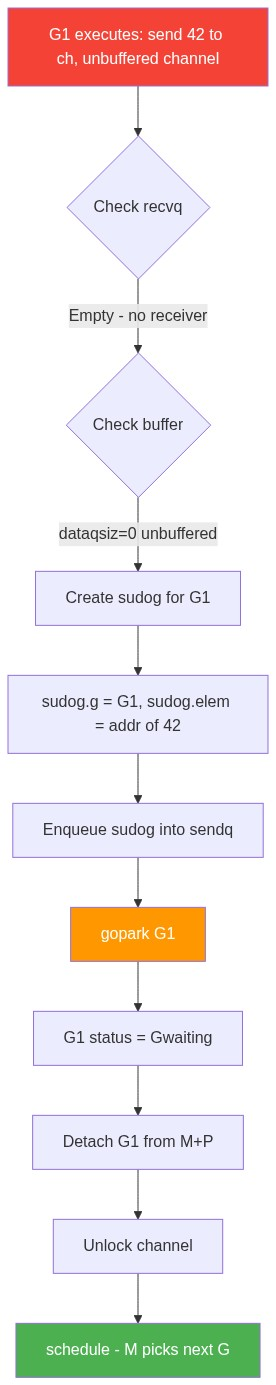

In [ ]:
mermaid("""flowchart TD
    A["G1 executes: send 42 to ch, unbuffered channel"] --> B{"Check recvq"}
    B -->|"Empty - no receiver"| C{"Check buffer"}
    C -->|"dataqsiz=0 unbuffered"| D["Create sudog for G1"]
    D --> E["sudog.g = G1, sudog.elem = addr of 42"]
    E --> F["Enqueue sudog into sendq"]
    F --> G["gopark G1"]
    G --> H["G1 status = Gwaiting"]
    H --> I["Detach G1 from M+P"]
    I --> J["Unlock channel"]
    J --> K["schedule - M picks next G"]

    style A fill:#f44336,color:#fff
    style G fill:#FF9800,color:#fff
    style K fill:#4CAF50,color:#fff""")


### Buffered Channel Full — No Receiver

```go
ch := make(chan int, 2)
ch <- 1   // succeeds, buffer: [1, _]
ch <- 2   // succeeds, buffer: [1, 2]
ch <- 3   // BLOCKS! buffer is full
```

Same flow: check recvq is empty, check buffer is full (`qcount == dataqsiz`), create sudog, add to sendq, `gopark(G)`.

### Sender Blocking and Resume Timeline

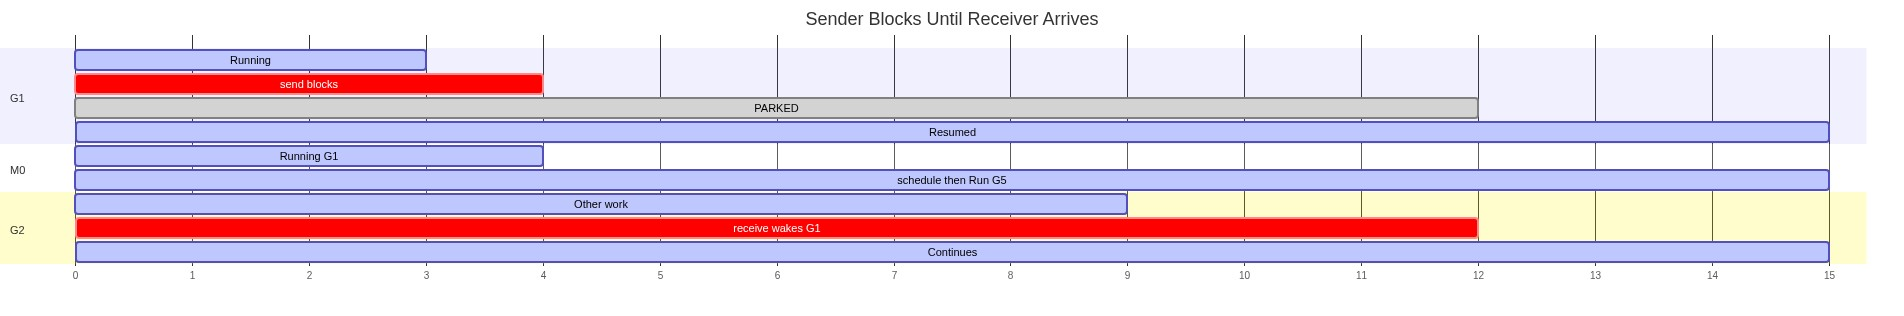

In [ ]:
mermaid("""gantt
    title Sender Blocks Until Receiver Arrives
    dateFormat X
    axisFormat %s

    section G1
    Running              :active, g1r, 0, 3
    send blocks          :crit, g1b, 3, 4
    PARKED               :done, g1p, 4, 12
    Resumed              :active, g1res, 12, 15

    section M0
    Running G1           :active, m1, 0, 4
    schedule then Run G5 :active, m2, 4, 15

    section G2
    Other work           :active, g2w, 0, 9
    receive wakes G1     :crit, g2r, 9, 12
    Continues            :active, g2c, 12, 15""")


---
## 6. How a Goroutine Resumes

A goroutine resumes when the event it was waiting for occurs. The runtime function `goready(g)` handles this.

### The goready Path

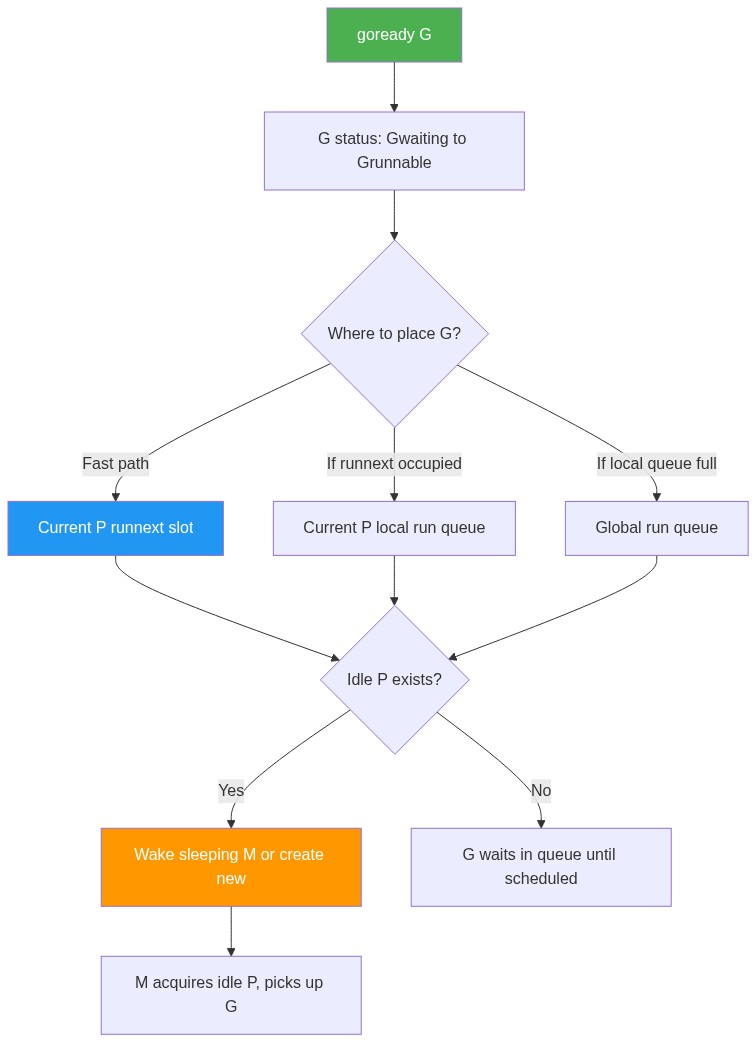

In [ ]:
mermaid("""flowchart TD
    A["goready G"] --> B["G status: Gwaiting to Grunnable"]
    B --> C{"Where to place G?"}
    C -->|"Fast path"| D["Current P runnext slot"]
    C -->|"If runnext occupied"| E["Current P local run queue"]
    C -->|"If local queue full"| F["Global run queue"]
    D --> G{"Idle P exists?"}
    E --> G
    F --> G
    G -->|Yes| H["Wake sleeping M or create new"]
    G -->|No| I["G waits in queue until scheduled"]
    H --> J["M acquires idle P, picks up G"]

    style A fill:#4CAF50,color:#fff
    style D fill:#2196F3,color:#fff
    style H fill:#FF9800,color:#fff""")


### Different Resume Triggers

| Blocked On | Who Calls `goready()`? |
|------------|----------------------|
| Channel receive (`<-ch`) | The goroutine that sends on the channel |
| Channel send (`ch<-`) | The goroutine that receives from the channel |
| `Mutex.Lock()` | The goroutine that calls `Unlock()` |
| `WaitGroup.Wait()` | Last goroutine to call `Done()` |
| `time.Sleep` / Timer | Timer heap check in sysmon/scheduler |
| Network I/O | Netpoller (epoll/kqueue wakes it) |
| Blocking syscall | Syscall returns, M tries to get a P |
| `select` | Whichever case becomes ready first |
| `Cond.Wait()` | Goroutine calling `Signal()`/`Broadcast()` |

### Detailed Resume: Channel Send Unblocks Receiver

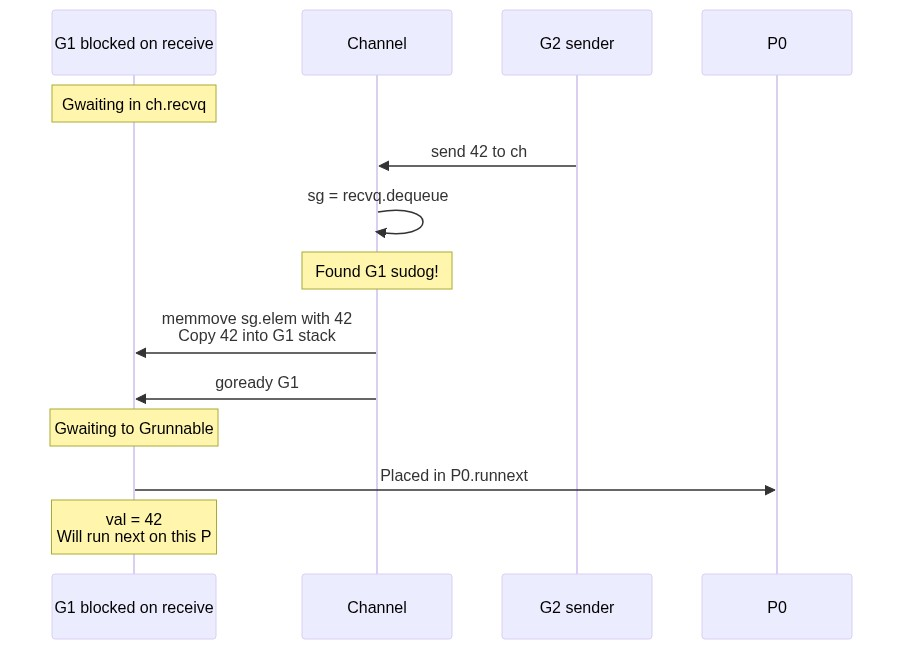

In [ ]:
mermaid("""sequenceDiagram
    participant G1 as G1 blocked on receive
    participant CH as Channel
    participant G2 as G2 sender
    participant P as P0

    Note over G1: Gwaiting in ch.recvq

    G2->>CH: send 42 to ch
    CH->>CH: sg = recvq.dequeue
    Note over CH: Found G1 sudog!

    CH->>G1: memmove sg.elem with 42<br/>Copy 42 into G1 stack
    CH->>G1: goready G1
    Note over G1: Gwaiting to Grunnable

    G1->>P: Placed in P0.runnext
    Note over G1: val = 42<br/>Will run next on this P""")


---
## 7. How `select` Works

`select` lets a goroutine wait on multiple channel operations simultaneously.

### Basic Semantics

```go
select {
case msg := <-ch1:     // case 0
    handle(msg)
case ch2 <- value:     // case 1
    fmt.Println("sent")
case <-time.After(5s): // case 2
    fmt.Println("timeout")
default:               // optional
    fmt.Println("nothing ready")
}
```

### Internal Implementation: runtime.selectgo

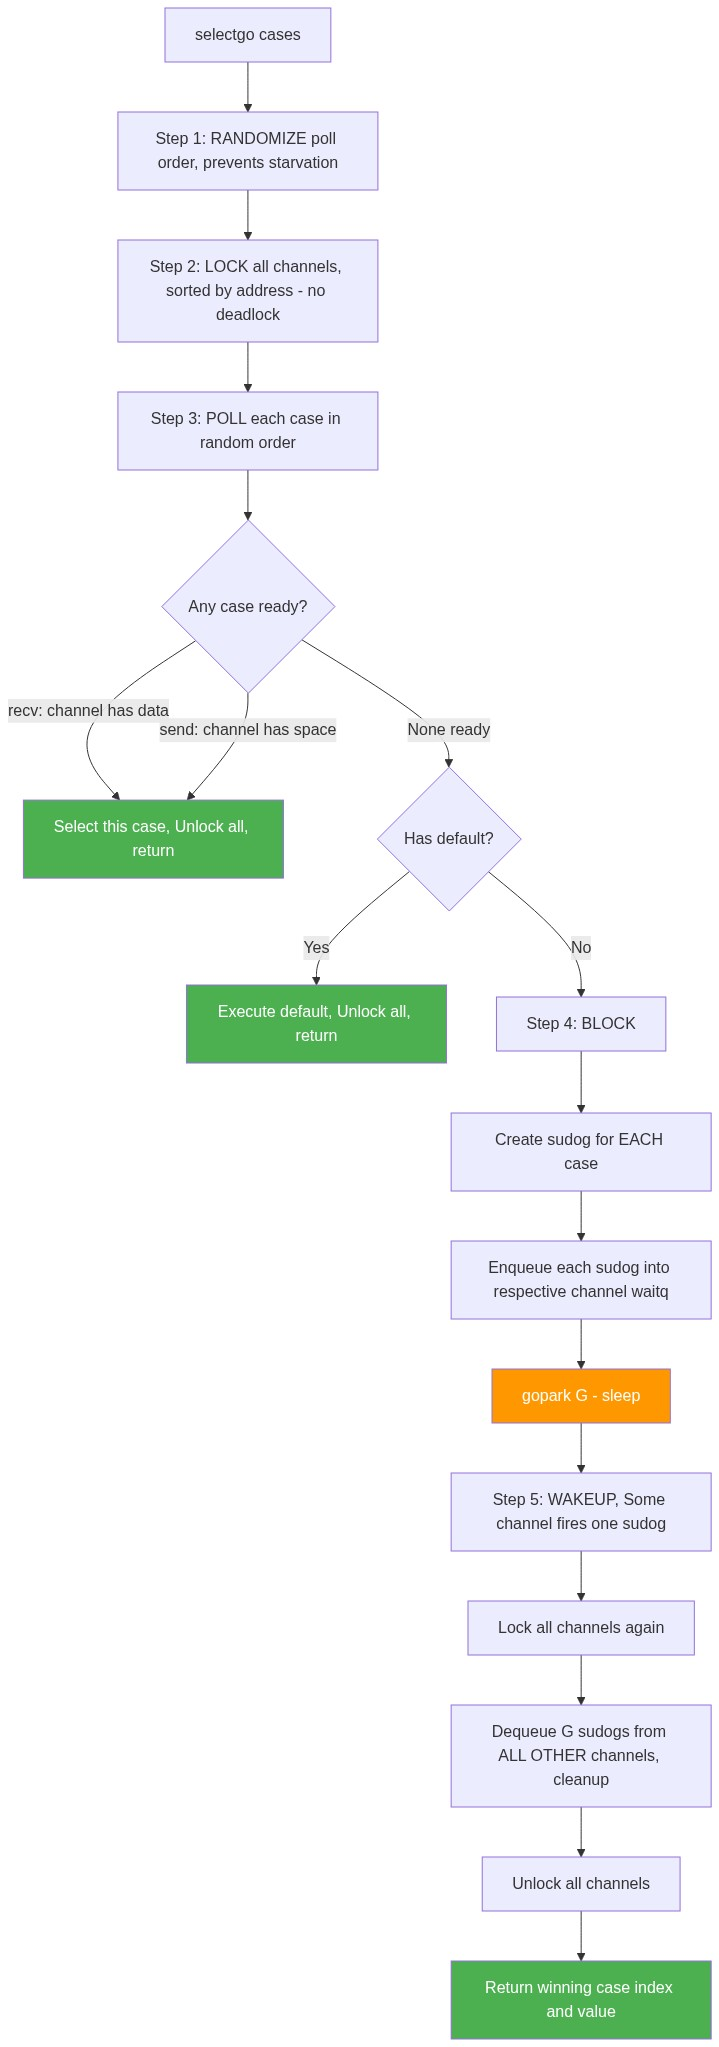

In [ ]:
mermaid("""flowchart TD
    A["selectgo cases"] --> B["Step 1: RANDOMIZE poll order, prevents starvation"]
    B --> C["Step 2: LOCK all channels, sorted by address - no deadlock"]
    C --> D["Step 3: POLL each case in random order"]

    D --> E{"Any case ready?"}
    E -->|"recv: channel has data"| WIN["Select this case, Unlock all, return"]
    E -->|"send: channel has space"| WIN

    E -->|"None ready"| F{"Has default?"}
    F -->|Yes| DEF["Execute default, Unlock all, return"]
    F -->|No| G["Step 4: BLOCK"]

    G --> H["Create sudog for EACH case"]
    H --> I["Enqueue each sudog into respective channel waitq"]
    I --> J["gopark G - sleep"]

    J --> K["Step 5: WAKEUP, Some channel fires one sudog"]
    K --> L["Lock all channels again"]
    L --> M["Dequeue G sudogs from ALL OTHER channels, cleanup"]
    M --> N["Unlock all channels"]
    N --> O["Return winning case index and value"]

    style WIN fill:#4CAF50,color:#fff
    style DEF fill:#4CAF50,color:#fff
    style O fill:#4CAF50,color:#fff
    style J fill:#FF9800,color:#fff""")


### Select Blocking on Multiple Channels

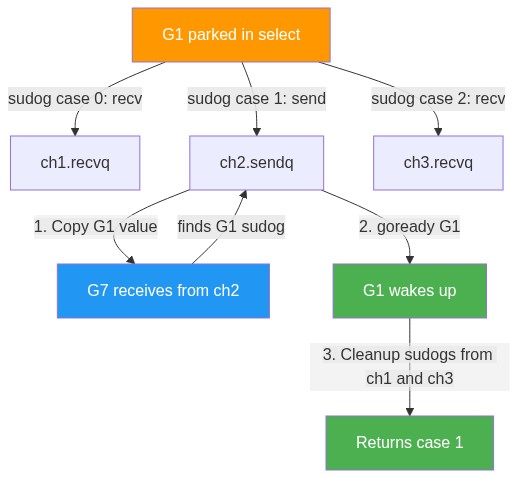

In [ ]:
mermaid("""graph TB
    G1["G1 parked in select"]

    G1 -->|"sudog case 0: recv"| CH1["ch1.recvq"]
    G1 -->|"sudog case 1: send"| CH2["ch2.sendq"]
    G1 -->|"sudog case 2: recv"| CH3["ch3.recvq"]

    G7["G7 receives from ch2"] -->|"finds G1 sudog"| CH2

    CH2 -->|"1. Copy G1 value"| G7
    CH2 -->|"2. goready G1"| G1_WAKE["G1 wakes up"]
    G1_WAKE -->|"3. Cleanup sudogs from ch1 and ch3"| DONE["Returns case 1"]

    style G1 fill:#FF9800,color:#fff
    style G1_WAKE fill:#4CAF50,color:#fff
    style DONE fill:#4CAF50,color:#fff
    style G7 fill:#2196F3,color:#fff""")


### `select{}` — Block Forever

```go
select {}  // zero cases, blocks the goroutine forever
```
Used to keep `main()` alive when all real work is in goroutines.

---
## 8. How a Goroutine Blocked on a Channel Resumes

This section ties together sections 4, 6, and 7 with concrete scenarios.

### Scenario A: Unbuffered Channel — Sender Wakes Receiver

```go
// G1                           // G2
val := <-ch  // blocks          ch <- 42  // wakes G1
```

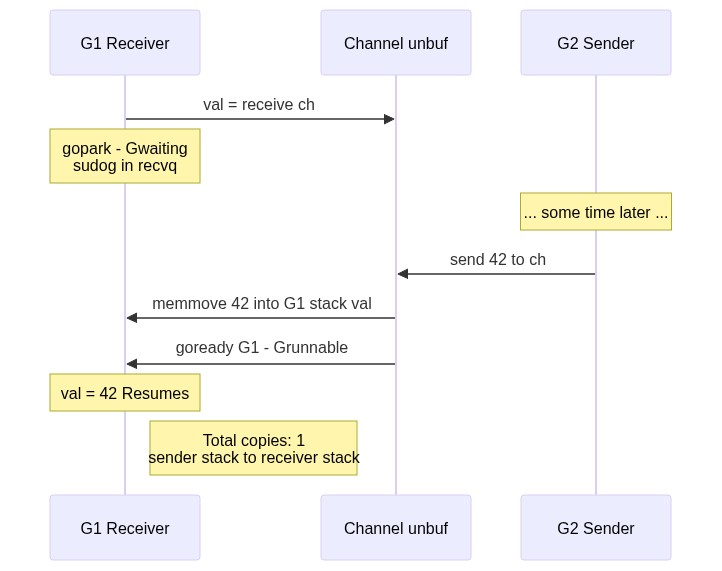

In [ ]:
mermaid("""sequenceDiagram
    participant G1 as G1 Receiver
    participant CH as Channel unbuf
    participant G2 as G2 Sender

    G1->>CH: val = receive ch
    Note over G1: gopark - Gwaiting<br/>sudog in recvq

    Note over G2: ... some time later ...

    G2->>CH: send 42 to ch
    CH->>G1: memmove 42 into G1 stack val
    CH->>G1: goready G1 - Grunnable
    Note over G1: val = 42 Resumes

    Note right of G1: Total copies: 1<br/>sender stack to receiver stack""")


### Scenario B: Buffered Channel — Buffer Drains to Wake Sender

```go
ch := make(chan int, 1)
// G1                           // G2
ch <- 1 // succeeds
ch <- 2 // blocks (full)        val := <-ch // wakes G1
```

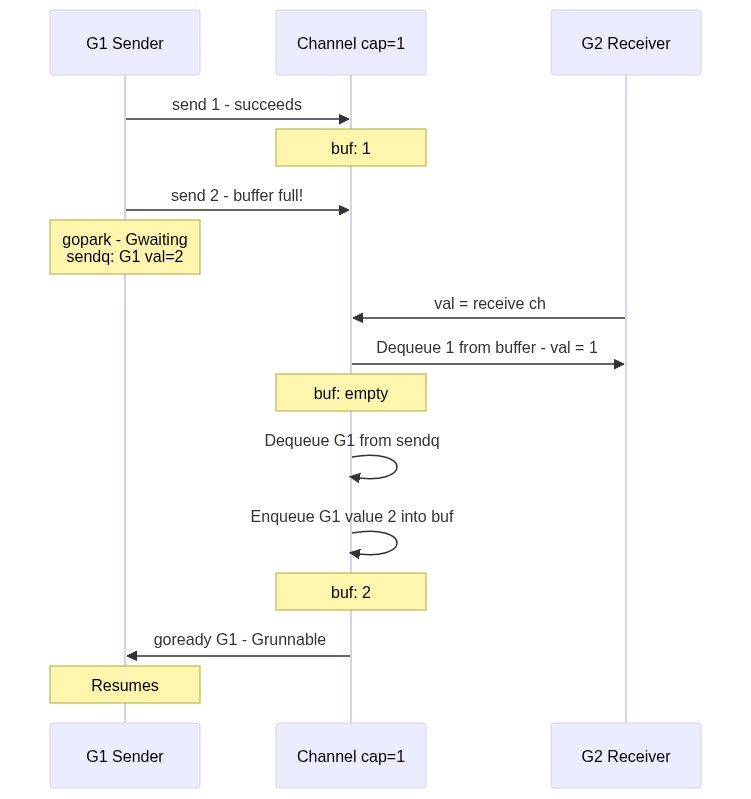

In [ ]:
mermaid("""sequenceDiagram
    participant G1 as G1 Sender
    participant CH as Channel cap=1
    participant G2 as G2 Receiver

    G1->>CH: send 1 - succeeds
    Note over CH: buf: 1
    G1->>CH: send 2 - buffer full!
    Note over G1: gopark - Gwaiting<br/>sendq: G1 val=2

    G2->>CH: val = receive ch
    CH->>G2: Dequeue 1 from buffer - val = 1
    Note over CH: buf: empty
    CH->>CH: Dequeue G1 from sendq
    CH->>CH: Enqueue G1 value 2 into buf
    Note over CH: buf: 2
    CH->>G1: goready G1 - Grunnable
    Note over G1: Resumes""")


### Scenario C: Select Resumes on First Ready Channel

```go
// G1
select {
case a := <-ch1:    // waiting
case b := <-ch2:    // waiting  <- this one fires
}

// G3 sends on ch2
ch2 <- "hello"
```

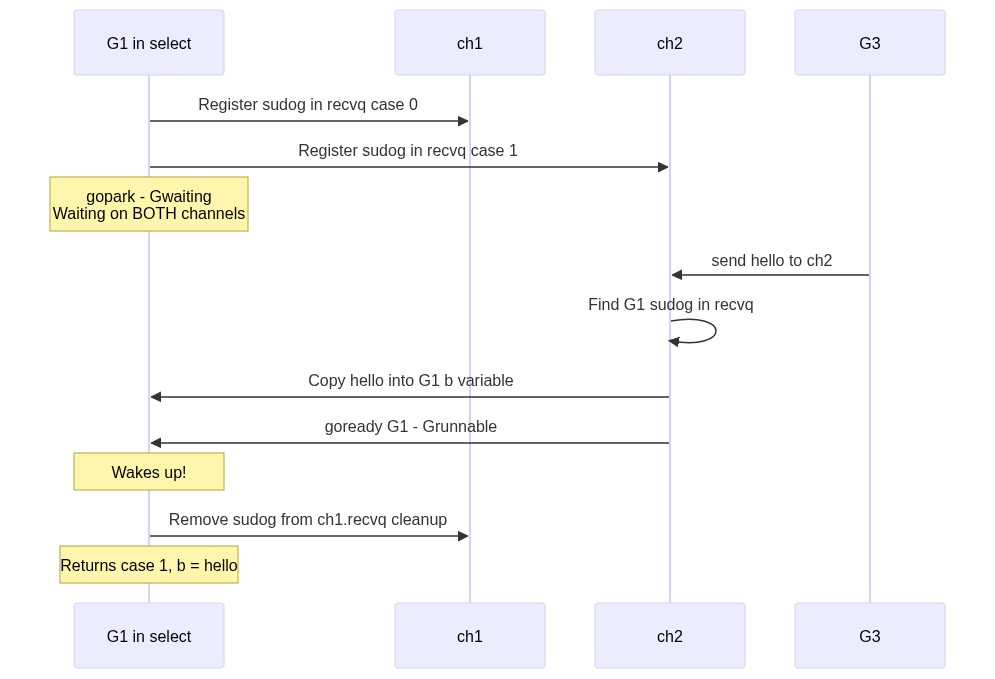

In [ ]:
mermaid("""sequenceDiagram
    participant G1 as G1 in select
    participant CH1 as ch1
    participant CH2 as ch2
    participant G3 as G3

    G1->>CH1: Register sudog in recvq case 0
    G1->>CH2: Register sudog in recvq case 1
    Note over G1: gopark - Gwaiting<br/>Waiting on BOTH channels

    G3->>CH2: send hello to ch2
    CH2->>CH2: Find G1 sudog in recvq
    CH2->>G1: Copy hello into G1 b variable
    CH2->>G1: goready G1 - Grunnable

    Note over G1: Wakes up!
    G1->>CH1: Remove sudog from ch1.recvq cleanup
    Note over G1: Returns case 1, b = hello""")


### Scenario D: Timer Resumes a Sleeping Goroutine

```go
time.Sleep(100 * time.Millisecond)
```

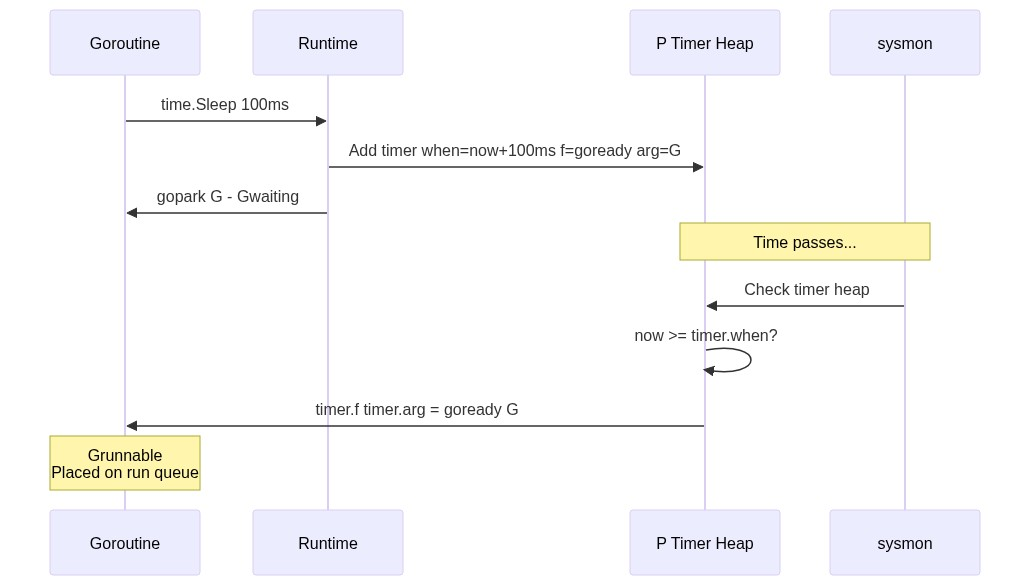

In [ ]:
mermaid("""sequenceDiagram
    participant G as Goroutine
    participant RT as Runtime
    participant TH as P Timer Heap
    participant SM as sysmon

    G->>RT: time.Sleep 100ms
    RT->>TH: Add timer when=now+100ms f=goready arg=G
    RT->>G: gopark G - Gwaiting

    Note over SM,TH: Time passes...

    SM->>TH: Check timer heap
    TH->>TH: now >= timer.when?
    TH->>G: timer.f timer.arg = goready G
    Note over G: Grunnable<br/>Placed on run queue""")


---
## Quick Reference: The Complete Goroutine Lifecycle

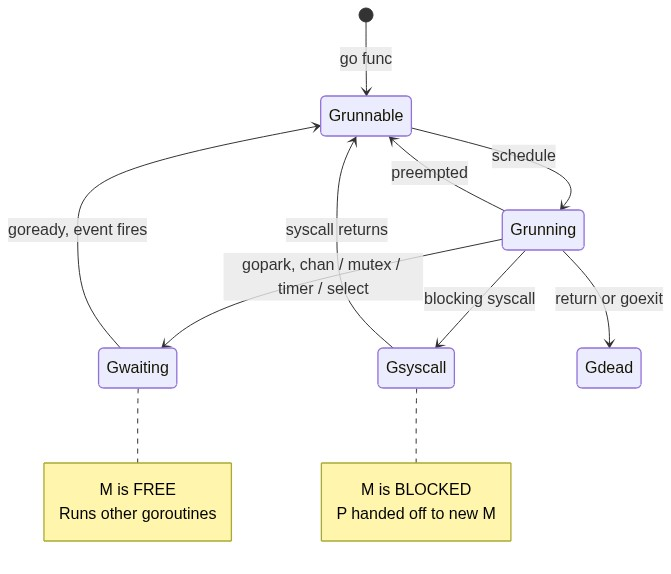

In [ ]:
mermaid("""stateDiagram-v2
    [*] --> Grunnable : go func

    Grunnable --> Grunning : schedule
    Grunning --> Grunnable : preempted

    Grunning --> Gwaiting : gopark, chan / mutex / timer / select
    Gwaiting --> Grunnable : goready, event fires

    Grunning --> Gsyscall : blocking syscall
    Gsyscall --> Grunnable : syscall returns

    Grunning --> Gdead : return or goexit

    note right of Gwaiting
        M is FREE
        Runs other goroutines
    end note

    note right of Gsyscall
        M is BLOCKED
        P handed off to new M
    end note""")


### Key Takeaways

| Concept | Summary |
|---------|--------|
| **M:N scheduling** | Many goroutines multiplexed onto fewer OS threads |
| **Channel block** | Goroutine parks, thread is free — zero thread waste |
| **Syscall block** | Thread is stuck, P is handed off to keep other Gs running |
| **Direct send** | Sender copies value straight into parked receiver's stack |
| **select** | Registers sudogs on ALL channels, first to fire wins, rest cleaned up |
| **Work stealing** | Idle Ps steal from busy Ps' queues — load balancing |
| **gopark/goready** | The fundamental park/resume primitives of the scheduler |
| **sysmon** | Watchdog that ensures stuck syscalls and long-running Gs don't starve others |

---

*References: Go runtime source (`runtime/proc.go`, `runtime/chan.go`, `runtime/select.go`, `runtime/netpoll.go`)*